# Q3(b) — Difference Image (Manual Homography)

## Objective
Subtract the warped c1 image from c2 to find the differences 
between the two circuit boards.

Since the assignment confirms both images are of the **same board** 
(manually transformed), the difference image should be close to zero 
everywhere if the homography was accurate.

Bright regions in the difference image indicate areas where the 
two images do not align — either due to:
- Inaccurate manual point selection in Q3(a)
- Slight lighting or exposure differences between the two photos
- Minor perspective distortion that homography could not fully correct

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

## Step 1 — Reload images and recompute the warped image
We redo the same steps as Q3(a) to get the warped image.
This keeps the notebook self-contained and runnable on its own.

In [6]:
# reload both images - same as q3a
im1 = cv2.imread('../images/c1.jpg', cv2.IMREAD_REDUCED_COLOR_4)
im2 = cv2.imread('../images/c2.jpg', cv2.IMREAD_REDUCED_COLOR_4)

im1_rgb = cv2.cvtColor(im1, cv2.COLOR_BGR2RGB)
im2_rgb = cv2.cvtColor(im2, cv2.COLOR_BGR2RGB)

# same 6 manually selected points from q3a
pts1 = np.float32([
    [210,  95],   # DC power jack base
    [390,  60],   # USB port top corner
    [105, 595],   # bottom-left mounting hole
    [415, 590],   # bottom-right mounting hole
    [220, 295],   # top-left ATmega corner
    [340, 390],   # bottom-right ATmega corner
])

pts2 = np.float32([
    [175, 110],   # DC power jack base
    [400,  55],   # USB port top corner
    [ 95, 540],   # bottom-left mounting hole
    [420, 530],   # bottom-right mounting hole
    [215, 270],   # top-left ATmega corner
    [345, 360],   # bottom-right ATmega corner
])

# recompute homography
H, mask = cv2.findHomography(pts1, pts2, cv2.RANSAC, 5.0)

# warp c1 to perspective of c2
h, w = im2.shape[:2]
im1_warped = cv2.warpPerspective(im1, H, (w, h))
im1_warped_rgb = cv2.cvtColor(im1_warped, cv2.COLOR_BGR2RGB)

print(f"c2 size       : {im2.shape[1]} x {im2.shape[0]}")
print(f"warped c1 size: {im1_warped.shape[1]} x {im1_warped.shape[0]}")
print("Images ready for subtraction")

c2 size       : 579 x 626
warped c1 size: 579 x 626
Images ready for subtraction


## Step 2 — Compute the difference image
We subtract the warped c1 from c2 pixel by pixel.

We use cv2.absdiff instead of simple subtraction because:
- Simple subtraction can produce negative values which wrap around
- absdiff gives the absolute difference so all values stay positive
- This makes bright pixels = large difference, dark pixels = similar

In [7]:
# compute absolute difference between c2 and warped c1
diff = cv2.absdiff(im2, im1_warped)

# convert to RGB for display
diff_rgb = cv2.cvtColor(diff, cv2.COLOR_BGR2RGB)

print(f"Max difference value : {diff.max()}")
print(f"Mean difference value: {diff.mean():.2f}")
print(f"Areas with diff > 30 : {(diff > 30).sum()} pixels")

Max difference value : 255
Mean difference value: 32.18
Areas with diff > 30 : 286577 pixels


## Step 3 — Display results
We show three images side by side:
- c2 (reference)
- warped c1
- difference image

We also show an enhanced version of the difference by scaling 
it up so small differences are more visible.

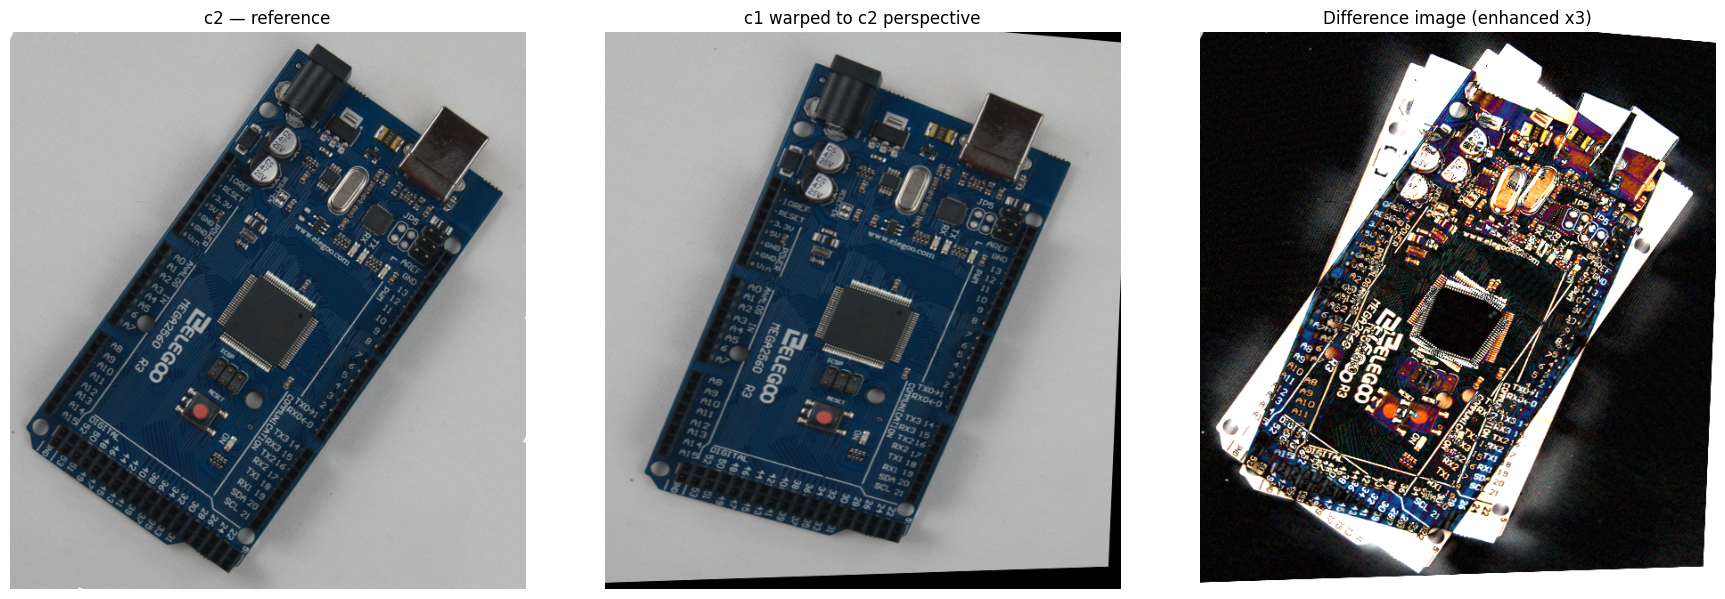

Difference image saved to images/q3b_difference_manual.png


In [8]:
# scale up the difference for better visibility
# multiply by 3 so small differences become visible
diff_enhanced = np.clip(diff_rgb.astype(np.float32) * 3, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(im2_rgb)
axes[0].set_title('c2 — reference')
axes[0].axis('off')

axes[1].imshow(im1_warped_rgb)
axes[1].set_title('c1 warped to c2 perspective')
axes[1].axis('off')

axes[2].imshow(diff_enhanced)
axes[2].set_title('Difference image (enhanced x3)')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('../images/q3b_difference_manual.png', dpi=150)
plt.show()
print("Difference image saved to images/q3b_difference_manual.png")

## Results Summary

| Metric | Value |
|--------|-------|
| Max difference value  | 255 |
| Mean difference value | 32.18 |
| Pixels with diff > 30 | 286,577 pixels |

## Observation
The difference image shows two overlapping board outlines which 
means the manual homography did not perfectly align the two images.

The mean difference of 32.18 out of 255 is relatively high — about 
12.6% average pixel error. The large black regions in the difference 
image come from the warped image boundary where cv2.warpPerspective 
fills unmapped areas with black (0), which then creates a large 
artificial difference against c2's grey background.

The bright coloured regions along the board edges and component 
areas show where the board structures did not align after warping. 
This is mainly caused by:

1. Manual point selection was not pixel-perfect — we could only 
   estimate coordinates by eye from the grid display
2. Only 6 points were used — more points would constrain the 
   homography better
3. Slight lighting and exposure differences between c1 and c2

This result gives us a baseline. We expect the automated ORB 
approach in Q3(d) to produce a lower mean difference value because 
ORB finds many more precise correspondences automatically rather 
than relying on manual visual estimation.

git add notebooks/q3b_difference_image_manual.ipynb images/q3b_difference_manual.png

git commit -m "Q3(b): difference image from manual homography - complete"

git push origin main